In [281]:
# --------------------
# IMPORTS
# --------------------

# numerical and tabular data handling:
import pandas as pd
import numpy as np

# plotting / visualization:
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn utilities: splitting, scaling, metrics, models, Classifications:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,mean_squared_error,r2_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from xgboost import XGBClassifier

In [282]:
# --------------------
# DATA LOADING
# --------------------

# Read CSV file into pandas DataFrame:

df = pd.read_csv("/telecom_customer_churn_prediction_dataset.csv")

# Show first 5 rows to verify columns and sample values:

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [283]:
# --------------------
# INITIAL EXPLORATION
# --------------------

# Get summary statistics for numeric columns (count, mean, std, min, max, percentiles):

df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [284]:
# Show column data types and non-null counts:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [285]:
# Example filter: count rows where gender is 'Female' and Churn == Yes:
# This demonstrates how to query and verify categorical labels before mapping:

print(df.query("gender=='Female' and Churn=='Yes'").count())

customerID          939
gender              939
SeniorCitizen       939
Partner             939
Dependents          939
tenure              939
PhoneService        939
MultipleLines       939
InternetService     939
OnlineSecurity      939
OnlineBackup        939
DeviceProtection    939
TechSupport         939
StreamingTV         939
StreamingMovies     939
Contract            939
PaperlessBilling    939
PaymentMethod       939
MonthlyCharges      939
TotalCharges        939
Churn               939
dtype: int64


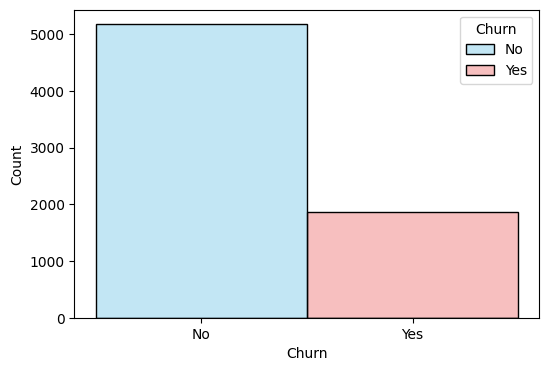

In [286]:
plt.figure(figsize=(6, 4))
sns.histplot(x="Churn", data=df, hue="Churn", palette=['skyblue', 'lightcoral'])
plt.show()

In [287]:
df['gender'].unique()

array(['Female', 'Male'], dtype=object)

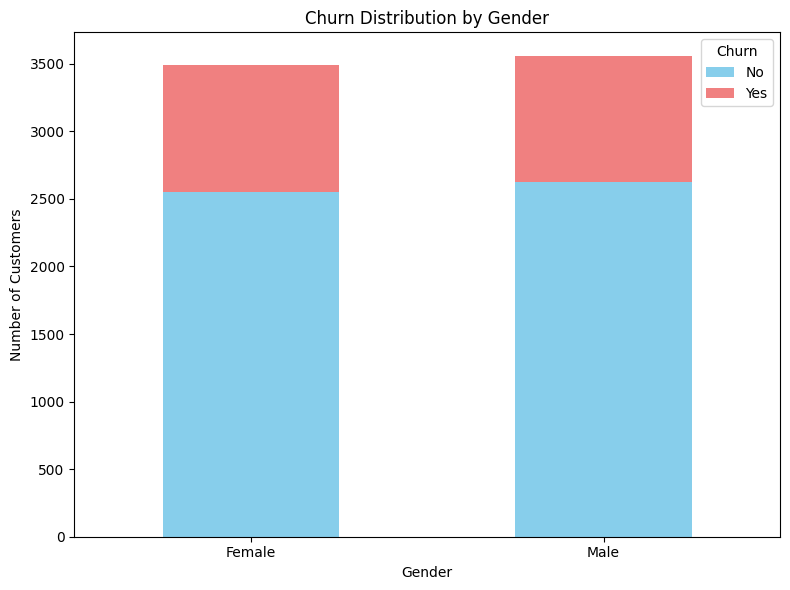

In [288]:
# Create a cross-tabulation of 'gender' and 'Churn'
churn_by_gender = pd.crosstab(df['gender'], df['Churn'])

# Plotting the stacked bar chart
churn_by_gender.plot(kind='bar', stacked=True, figsize=(8, 6), color=['skyblue', 'lightcoral'])
plt.title('Churn Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0) # Keep x-axis labels horizontal
plt.legend(title='Churn', labels=['No', 'Yes']) # Rename legend labels for clarity
plt.tight_layout()
plt.show()

In [289]:
df['SeniorCitizen'].unique()

array([0, 1])

In [290]:
df["SeniorCitizen"] = df["SeniorCitizen"].map({1: "Yes", 0: "No"})

In [291]:
print(df['SeniorCitizen'].value_counts())

SeniorCitizen
No     5901
Yes    1142
Name: count, dtype: int64


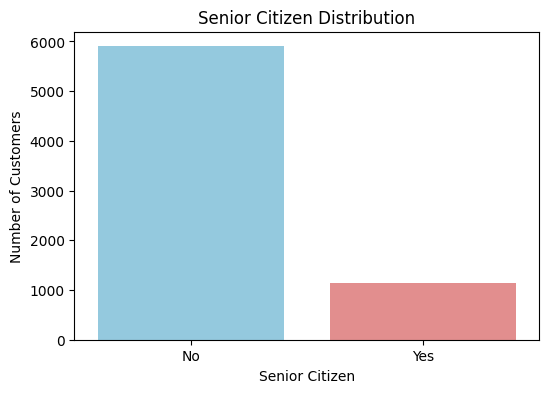

In [292]:
# Plotting the count plot
plt.figure(figsize=(6, 4))
sns.countplot(x="SeniorCitizen", data=df, hue="SeniorCitizen", palette=['skyblue', 'lightcoral'], legend=False)
plt.xlabel("Senior Citizen")
plt.ylabel('Number of Customers')
plt.title("Senior Citizen Distribution")
plt.show()

In [293]:
df['Partner'].unique()

array(['Yes', 'No'], dtype=object)

In [294]:
print(df['Partner'].value_counts())

Partner
No     3641
Yes    3402
Name: count, dtype: int64


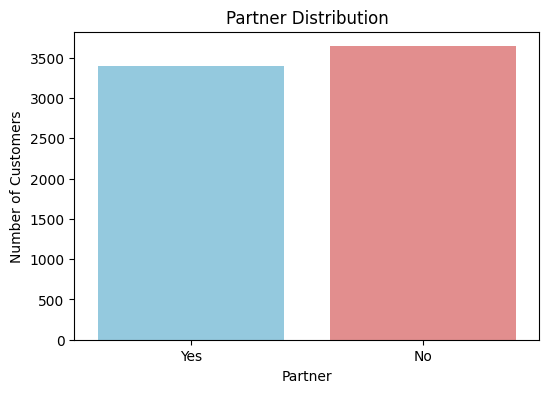

In [295]:
# Plotting the count plot
plt.figure(figsize=(6, 4))
sns.countplot(x="Partner", data=df, hue="Partner", palette=['skyblue', 'lightcoral'], legend=False)
plt.xlabel("Partner")
plt.ylabel('Number of Customers')
plt.title("Partner Distribution")
plt.show()

In [296]:
df['Dependents'].unique()

array(['No', 'Yes'], dtype=object)

In [297]:
print(df['Dependents'].value_counts())

Dependents
No     4933
Yes    2110
Name: count, dtype: int64


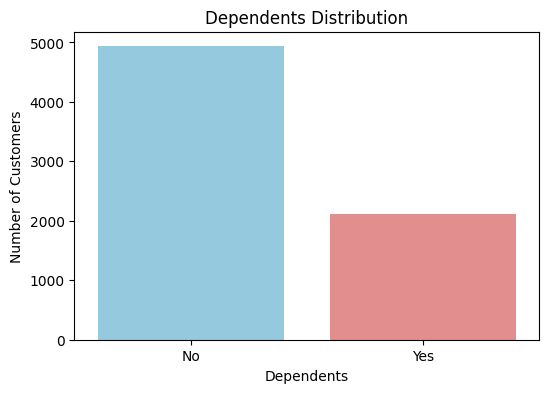

In [298]:
# Plotting the count plot
plt.figure(figsize=(6, 4))
sns.countplot(x="Dependents", data=df, hue="Dependents", palette=['skyblue', 'lightcoral'], legend=False)
plt.xlabel("Dependents")
plt.ylabel('Number of Customers')
plt.title("Dependents Distribution")
plt.show()

In [299]:
df['tenure'].unique()

array([ 1, 34,  2, 45,  8, 22, 10, 28, 62, 13, 16, 58, 49, 25, 69, 52, 71,
       21, 12, 30, 47, 72, 17, 27,  5, 46, 11, 70, 63, 43, 15, 60, 18, 66,
        9,  3, 31, 50, 64, 56,  7, 42, 35, 48, 29, 65, 38, 68, 32, 55, 37,
       36, 41,  6,  4, 33, 67, 23, 57, 61, 14, 20, 53, 40, 59, 24, 44, 19,
       54, 51, 26,  0, 39])

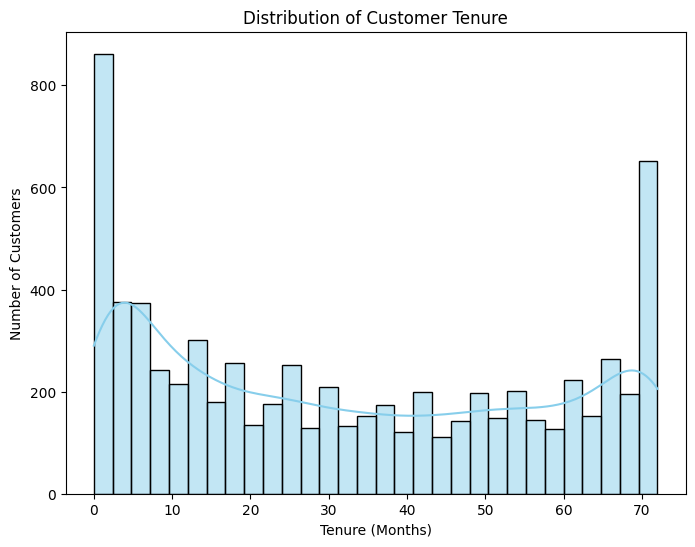

In [300]:
# Plotting the histogram
plt.figure(figsize=(8, 6))
sns.histplot(x='tenure', data=df, kde=True, bins=30, color='skyblue')
plt.title('Distribution of Customer Tenure')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')
plt.show()

In [301]:
df['PhoneService'].unique()

array(['No', 'Yes'], dtype=object)

In [302]:
print(df['PhoneService'].value_counts())

PhoneService
Yes    6361
No      682
Name: count, dtype: int64


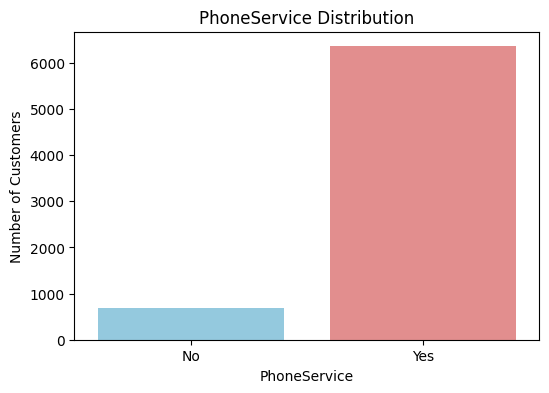

In [303]:
# Plotting the count plot
plt.figure(figsize=(6, 4))
sns.countplot(x="PhoneService", data=df, hue="PhoneService", palette=['skyblue', 'lightcoral'], legend=False)
plt.xlabel("PhoneService")
plt.ylabel('Number of Customers')
plt.title("PhoneService Distribution")
plt.show()

In [304]:
df['MultipleLines'].unique()

array(['No phone service', 'No', 'Yes'], dtype=object)

In [305]:
print(df['MultipleLines'].value_counts())

MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64


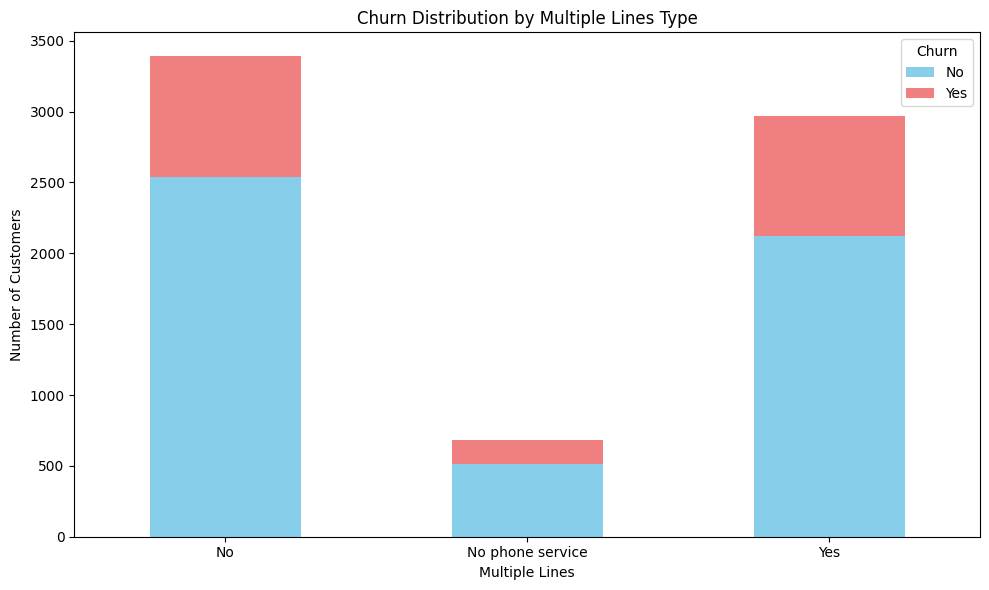

In [306]:
# Create a cross-tabulation of 'MultipleLines' and 'Churn'
multiple_lines_churn = pd.crosstab(df['MultipleLines'], df['Churn'])

# Plotting the stacked bar chart
multiple_lines_churn.plot(kind='bar', stacked=True, figsize=(10, 6), color=['skyblue', 'lightcoral'])
plt.title('Churn Distribution by Multiple Lines Type')
plt.xlabel('Multiple Lines')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.legend(title='Churn', labels=['No', 'Yes']) # Rename legend labels for clarity
plt.tight_layout()
plt.show()

In [307]:
df['InternetService'].unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

In [308]:
print(df['InternetService'].value_counts())

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64


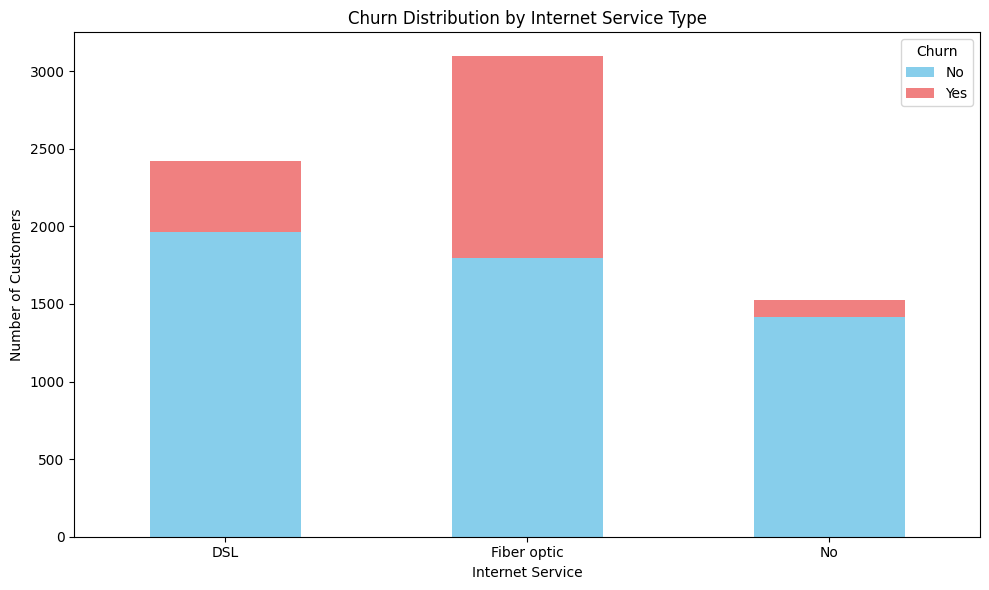

In [309]:
# Create a cross-tabulation of 'InternetService' and 'Churn'
internet_service_churn = pd.crosstab(df['InternetService'], df['Churn'])

# Plotting the stacked bar chart
internet_service_churn.plot(kind='bar', stacked=True, figsize=(10, 6), color=['skyblue', 'lightcoral'])
plt.title('Churn Distribution by Internet Service Type')
plt.xlabel('Internet Service')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.legend(title='Churn', labels=['No', 'Yes']) # Rename legend labels for clarity
plt.tight_layout()
plt.show()

In [310]:
df['OnlineSecurity'].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

In [311]:
print(df['OnlineSecurity'].value_counts())

OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64


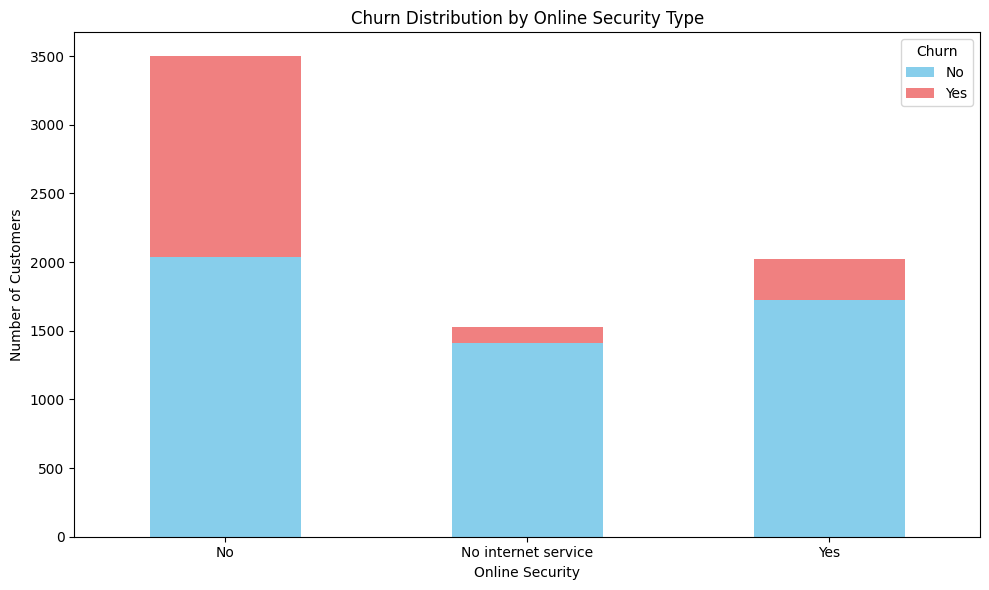

In [312]:
# Create a cross-tabulation of 'OnlineSecurity' and 'Churn'
Online_Security_churn = pd.crosstab(df['OnlineSecurity'], df['Churn'])

# Plotting the stacked bar chart
Online_Security_churn.plot(kind='bar', stacked=True, figsize=(10, 6), color=['skyblue', 'lightcoral'])
plt.title('Churn Distribution by Online Security Type')
plt.xlabel('Online Security')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.legend(title='Churn', labels=['No', 'Yes']) # Rename legend labels for clarity
plt.tight_layout()
plt.show()

In [313]:
df['OnlineBackup'].unique()

array(['Yes', 'No', 'No internet service'], dtype=object)

In [314]:
print(df['OnlineBackup'].value_counts())

OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64


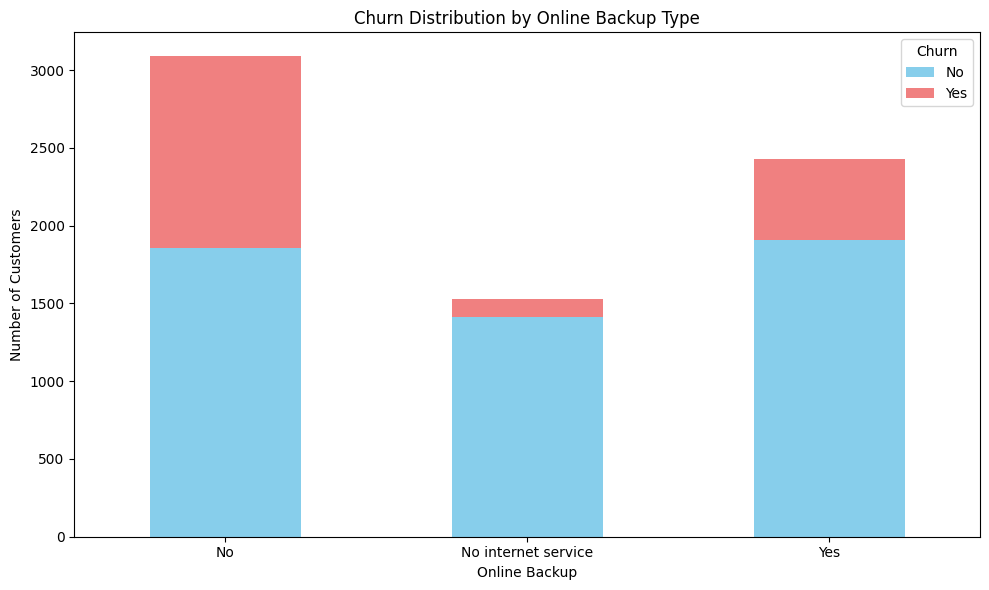

In [315]:
# Create a cross-tabulation of 'OnlineBackup' and 'Churn'
Online_Backup_churn = pd.crosstab(df['OnlineBackup'], df['Churn'])

# Plotting the stacked bar chart
Online_Backup_churn.plot(kind='bar', stacked=True, figsize=(10, 6), color=['skyblue', 'lightcoral'])
plt.title('Churn Distribution by Online Backup Type')
plt.xlabel('Online Backup')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.legend(title='Churn', labels=['No', 'Yes']) # Rename legend labels for clarity
plt.tight_layout()
plt.show()

In [316]:
df['DeviceProtection'].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

In [317]:
print(df['DeviceProtection'].value_counts())

DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64


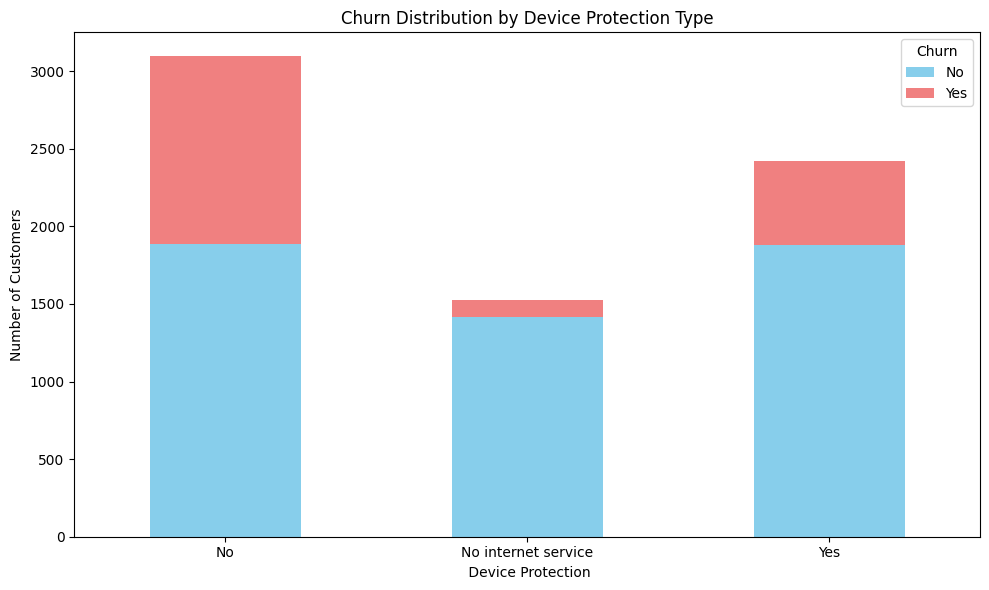

In [318]:
# Create a cross-tabulation of 'DeviceProtection' and 'Churn'
Device_Protection_churn = pd.crosstab(df['DeviceProtection'], df['Churn'])

# Plotting the stacked bar chart
Device_Protection_churn .plot(kind='bar', stacked=True, figsize=(10, 6), color=['skyblue', 'lightcoral'])
plt.title('Churn Distribution by Device Protection Type')
plt.xlabel(' Device Protection')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.legend(title='Churn', labels=['No', 'Yes']) # Rename legend labels for clarity
plt.tight_layout()
plt.show()

In [319]:
df['TechSupport'].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

In [320]:
print(df['TechSupport'].value_counts())

TechSupport
No                     3473
Yes                    2044
No internet service    1526
Name: count, dtype: int64


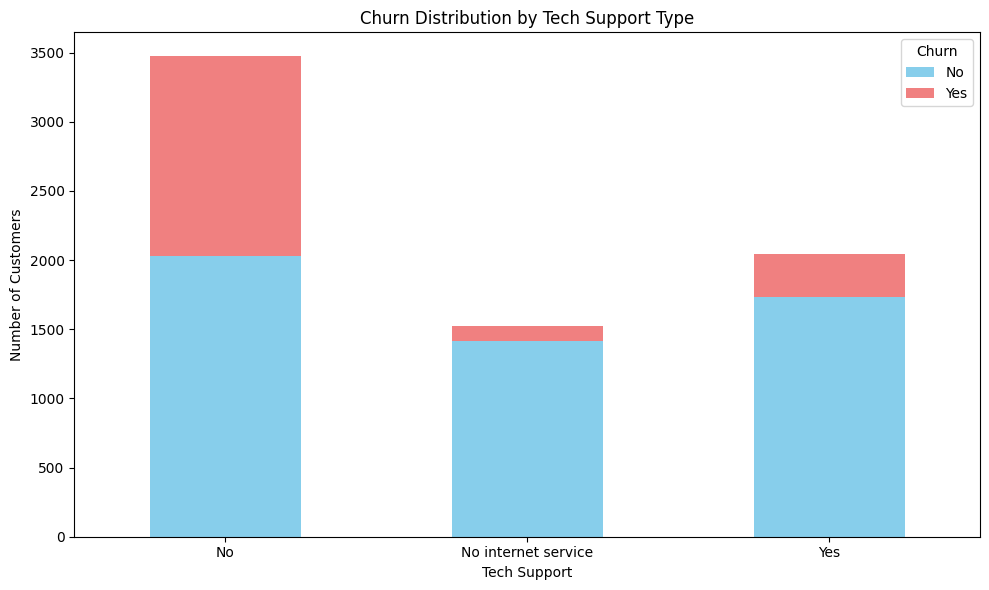

In [321]:
# Create a cross-tabulation of 'TechSupport' and 'Churn'
Tech_Support_churn = pd.crosstab(df['TechSupport'], df['Churn'])

# Plotting the stacked bar chart
Tech_Support_churn .plot(kind='bar', stacked=True, figsize=(10, 6), color=['skyblue', 'lightcoral'])
plt.title('Churn Distribution by Tech Support Type')
plt.xlabel('Tech Support')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.legend(title='Churn', labels=['No', 'Yes']) # Rename legend labels for clarity
plt.tight_layout()
plt.show()

In [322]:
df['StreamingTV'].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

In [323]:
print(df['StreamingTV'].value_counts())

StreamingTV
No                     2810
Yes                    2707
No internet service    1526
Name: count, dtype: int64


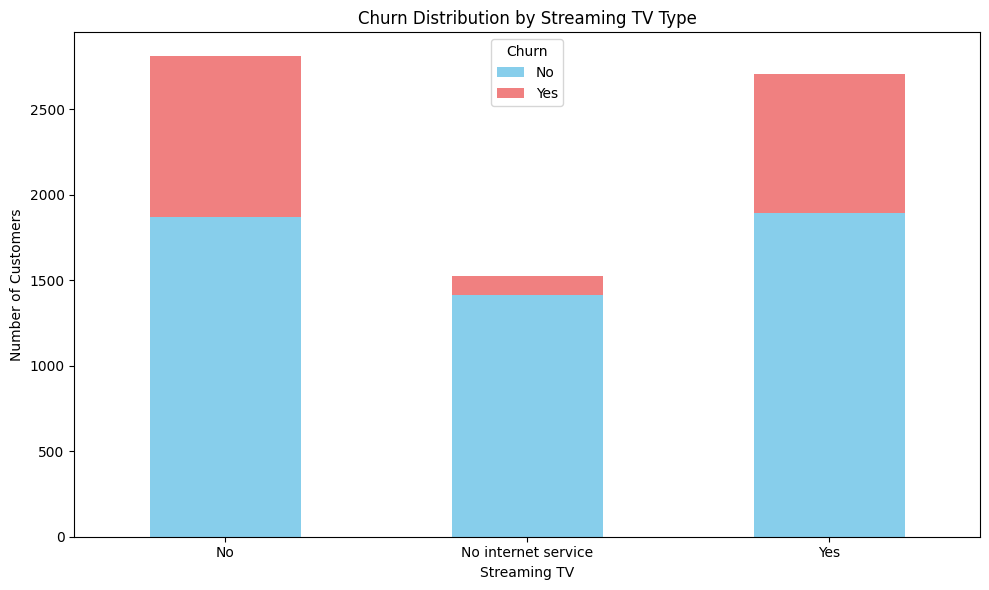

In [324]:
# Create a cross-tabulation of 'StreamingTV' and 'Churn'
Streaming_TV_churn = pd.crosstab(df['StreamingTV'], df['Churn'])

# Plotting the stacked bar chart
Streaming_TV_churn .plot(kind='bar', stacked=True, figsize=(10, 6), color=['skyblue', 'lightcoral'])
plt.title('Churn Distribution by Streaming TV Type')
plt.xlabel('Streaming TV')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.legend(title='Churn', labels=['No', 'Yes']) # Rename legend labels for clarity
plt.tight_layout()
plt.show()

In [325]:
df['StreamingMovies'].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

In [326]:
print(df['StreamingMovies'].value_counts())

StreamingMovies
No                     2785
Yes                    2732
No internet service    1526
Name: count, dtype: int64


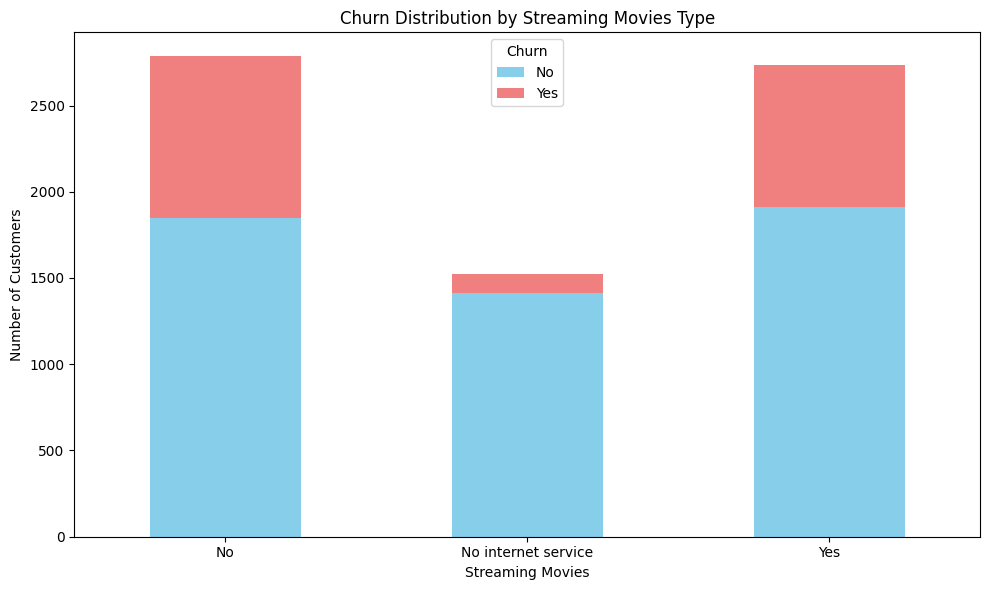

In [327]:
# Create a cross-tabulation of 'StreamingMovies' and 'Churn'
Streaming_Movies_churn = pd.crosstab(df['StreamingMovies'], df['Churn'])

# Plotting the stacked bar chart
Streaming_Movies_churn .plot(kind='bar', stacked=True, figsize=(10, 6), color=['skyblue', 'lightcoral'])
plt.title('Churn Distribution by Streaming Movies Type')
plt.xlabel('Streaming Movies')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.legend(title='Churn', labels=['No', 'Yes']) # Rename legend labels for clarity
plt.tight_layout()
plt.show()

In [328]:
df['Contract'].unique()

array(['Month-to-month', 'One year', 'Two year'], dtype=object)

In [329]:
print(df['Contract'].value_counts())

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64


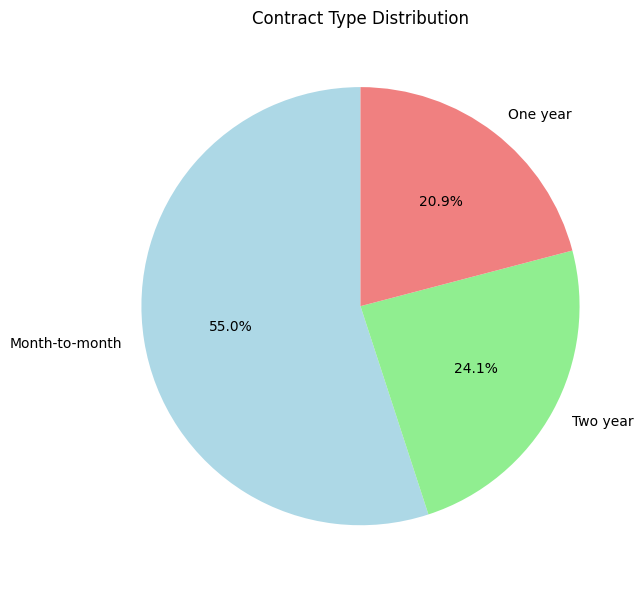

In [330]:
# Plotting the pie chart
plt.figure(figsize=(10, 6))
df['Contract'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=['lightblue', 'lightgreen', 'lightcoral']) #autopct is used to display percentage per slice
plt.title('Contract Type Distribution')
plt.ylabel('')
plt.tight_layout()
plt.show()

In [331]:
df['PaperlessBilling'].unique()

array(['Yes', 'No'], dtype=object)

In [332]:
print(df['PaperlessBilling'].value_counts())

PaperlessBilling
Yes    4171
No     2872
Name: count, dtype: int64


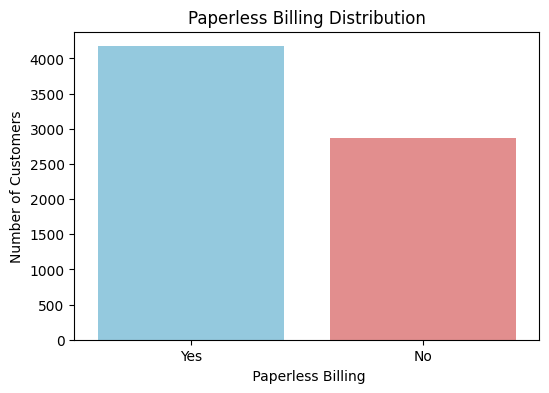

In [333]:
# Plotting the count plot
plt.figure(figsize=(6, 4))
sns.countplot(x="PaperlessBilling", data=df, hue="PaperlessBilling", palette=['skyblue', 'lightcoral'], legend=False)
plt.xlabel(" Paperless Billing")
plt.ylabel('Number of Customers')
plt.title("Paperless Billing Distribution")
plt.show()

In [334]:
df['PaymentMethod'].unique()

array(['Electronic check', 'Mailed check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

In [335]:
print(df['PaymentMethod'].value_counts())

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64


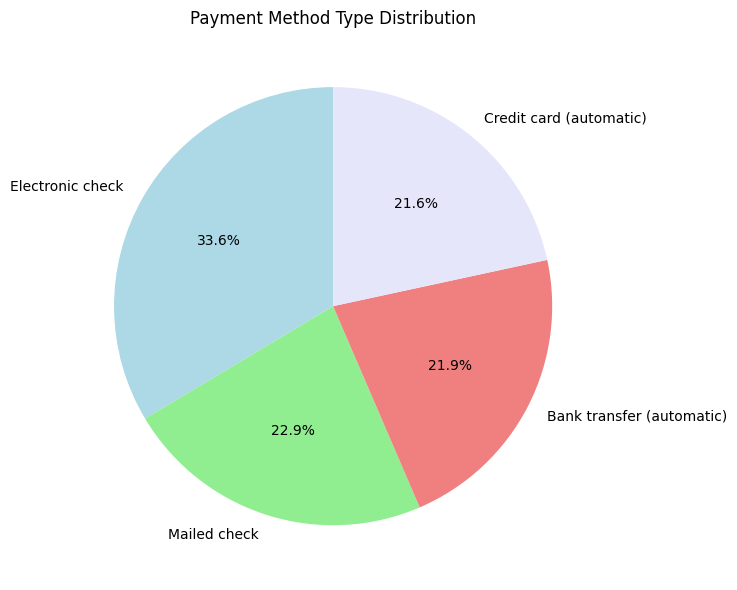

In [336]:
# Plotting the pie chart
plt.figure(figsize=(10, 6))
df['PaymentMethod'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=['lightblue', 'lightgreen', 'lightcoral','lavender'])#autopct is used to display percentage per slice
plt.title('Payment Method Type Distribution')
plt.ylabel('')
plt.tight_layout()
plt.show()

In [337]:
df['MonthlyCharges'].unique()

array([29.85, 56.95, 53.85, ..., 63.1 , 44.2 , 78.7 ])

In [338]:
print(df['MonthlyCharges'].value_counts())

MonthlyCharges
20.05     61
19.85     45
19.95     44
19.90     44
20.00     43
          ..
56.85      1
101.70     1
48.40      1
108.35     1
72.00      1
Name: count, Length: 1585, dtype: int64


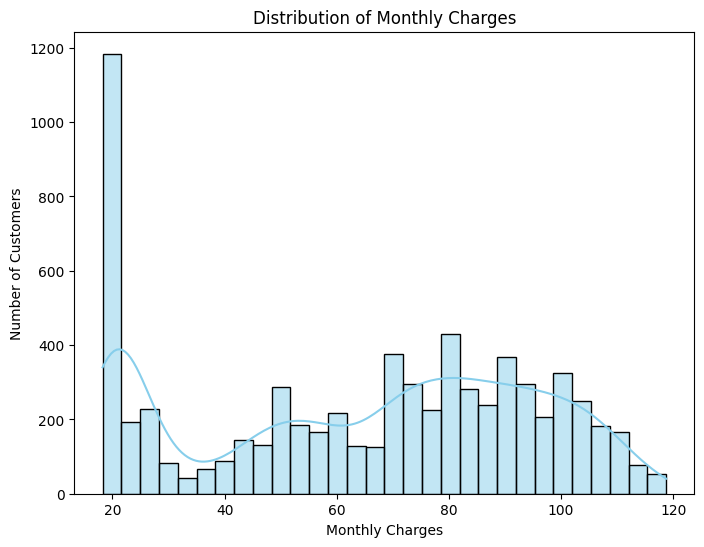

In [339]:

#Plotting the histogram
plt.figure(figsize=(8, 6))
sns.histplot(x='MonthlyCharges', data=df, kde=True, bins=30, color='skyblue')
plt.title('Distribution of Monthly Charges')
plt.xlabel('Monthly Charges')
plt.ylabel('Number of Customers')
plt.show()

In [340]:
df['TotalCharges'].unique()

array(['29.85', '1889.5', '108.15', ..., '346.45', '306.6', '6844.5'],
      dtype=object)

In [341]:
print(df['TotalCharges'].value_counts())

TotalCharges
           11
20.2       11
19.75       9
20.05       8
19.9        8
           ..
130.15      1
3211.9      1
7843.55     1
2196.3      1
197.4       1
Name: count, Length: 6531, dtype: int64


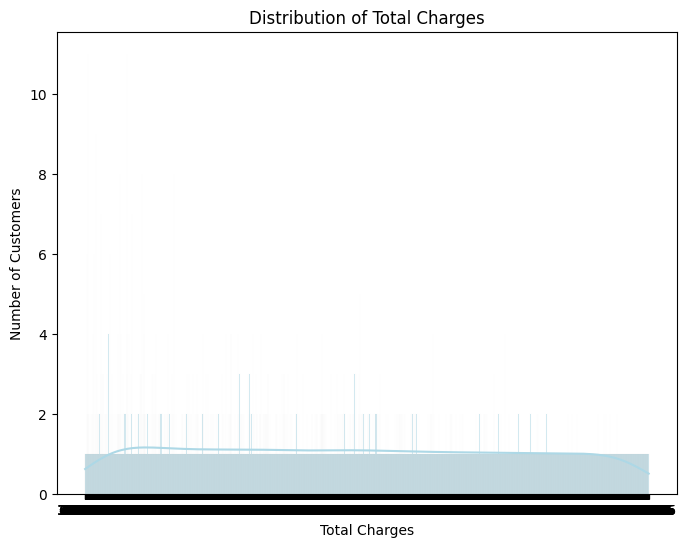

In [342]:
#Plotting the histogram
plt.figure(figsize=(8, 6))
sns.histplot(x='TotalCharges', data=df, kde=True, bins=70, color='lightblue')
plt.title('Distribution of Total Charges')
plt.xlabel('Total Charges')
plt.ylabel('Number of Customers')
plt.show()

In [343]:
df['Churn'].unique()

array(['No', 'Yes'], dtype=object)

In [344]:
print(df['Churn'].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


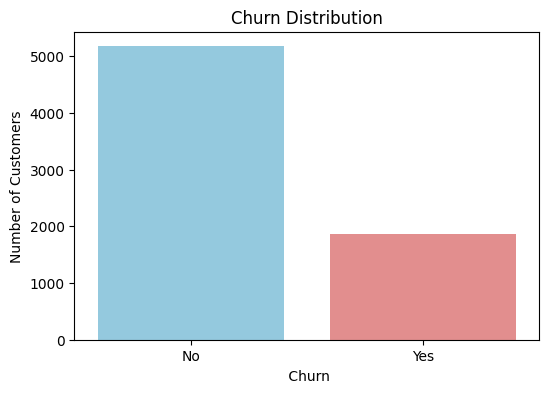

In [345]:
# Plotting the count plot
plt.figure(figsize=(6, 4))
sns.countplot(x="Churn", data=df, hue="Churn", palette=['skyblue', 'lightcoral'], legend=False)
plt.xlabel(" Churn")
plt.ylabel('Number of Customers')
plt.title("Churn Distribution")
plt.show()

In [346]:
# --------------------
# CATEGORICAL MAPPING (TEXT -> NUMERIC)
# --------------------

for col in df.select_dtypes(include=['object']).columns:
  if col != 'Churn':
    df[col] = LabelEncoder().fit_transform(df[col])


In [347]:
df['Churn'] = LabelEncoder().fit_transform(df['Churn'])

In [348]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,5375,0,0,1,0,1,0,1,0,0,...,0,0,0,0,0,1,2,29.85,2505,0
1,3962,1,0,0,0,34,1,0,0,2,...,2,0,0,0,1,0,3,56.95,1466,0
2,2564,1,0,0,0,2,1,0,0,2,...,0,0,0,0,0,1,3,53.85,157,1
3,5535,1,0,0,0,45,0,1,0,2,...,2,2,0,0,1,0,0,42.30,1400,0
4,6511,0,0,0,0,2,1,0,1,0,...,0,0,0,0,0,1,2,70.70,925,1


In [349]:
# --------------------
# PREPARE FEATURES AND TARGET
# --------------------

# Separate features (X) and target (y):

# drop target column -> features for modeling
X = df.drop('Churn',axis=1)

# keep target column separately
y = df['Churn']

In [350]:
# Split into train/test sets (80/20) with fixed random_state for reproducibility:

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [351]:
# Standardize training data (mean = 0, std = 1) using training statistics
# Apply the same scaling to test data without refitting

std = StandardScaler()
X_train = std.fit_transform(X_train)
X_test = std.transform(X_test)

In [352]:
# --------------------
# SUPERVISED MODELING
# --------------------

# 1) Logistic Regression:
# - Appropriate for binary classification; outputs class probabilities and labels.

# fit on training set
model_linear = LogisticRegression()
model_linear.fit(X_train,y_train)

y_pred = model_linear.predict(X_test)   # predicted labels on test set
print(y_pred)


[1 0 0 ... 0 0 0]


In [353]:
# compute accuracy

acc_log = accuracy_score(y_test, y_pred)
print(f"Accuracy-score: {acc_log}")

Accuracy-score: 0.8147622427253371


In [354]:
# Compute regression metrics to evaluate baseline behavior:

print(f"Mean-Squared-Error: {mean_squared_error(y_test, y_pred)}")
print(f"R2-Score: {r2_score(y_test, y_pred)}")

Mean-Squared-Error: 0.18523775727466288
R2-Score: 0.04833759458424358


In [355]:
print(confusion_matrix(y_test, y_pred))

[[940  96]
 [165 208]]


<Axes: >

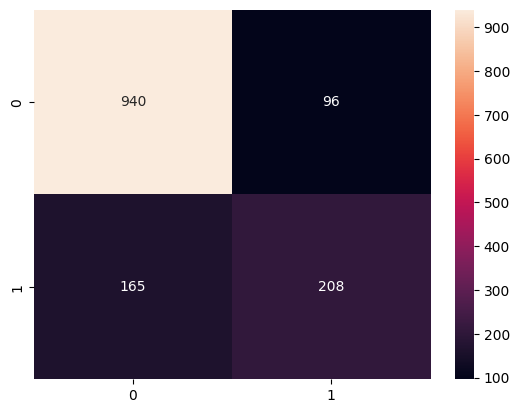

In [356]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d")

In [357]:
# Classification Report:

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.91      0.88      1036
           1       0.68      0.56      0.61       373

    accuracy                           0.81      1409
   macro avg       0.77      0.73      0.75      1409
weighted avg       0.81      0.81      0.81      1409



In [358]:
# 2) Decision Tree:
# - Train a Decision Tree classifier using Gini index on training data

decision_tree = DecisionTreeClassifier(criterion="gini", random_state=42).fit(X_train, y_train)
decision_tree

DecisionTreeClassifier(random_state=42)

In [359]:
y_pred = decision_tree.predict(X_test)
y_pred

array([1, 0, 0, ..., 0, 0, 1])

In [360]:
acc_dt = accuracy_score(y_test, y_pred)
print(f"Accuracy-score: {acc_dt}")

Accuracy-score: 0.7175301632363378


In [361]:
print(confusion_matrix(y_test, y_pred))

[[834 202]
 [196 177]]


<Axes: >

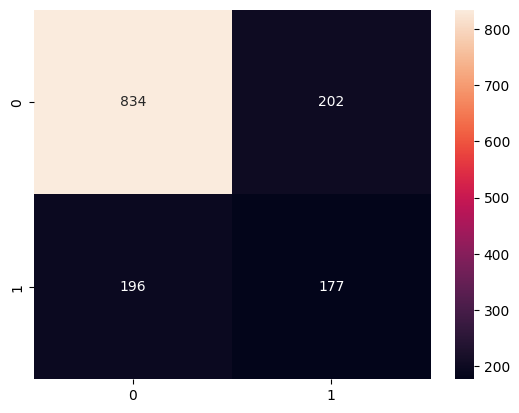

In [362]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d")

In [363]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.81      0.81      1036
           1       0.47      0.47      0.47       373

    accuracy                           0.72      1409
   macro avg       0.64      0.64      0.64      1409
weighted avg       0.72      0.72      0.72      1409



In [364]:
# 3) Random Forest:
# - Train a Random Forest using the same max depth as the Decision Tree for fair comparison

random_forest = RandomForestClassifier(max_depth=decision_tree.tree_.max_depth, random_state=42).fit(X_train, y_train)
random_forest

RandomForestClassifier(max_depth=26, random_state=42)

In [365]:
y_pred = random_forest.predict(X_test)
y_pred

array([1, 0, 0, ..., 0, 0, 1])

In [366]:
acc_rf = accuracy_score(y_test, y_pred)
print(f"Accuracy-score: {acc_rf}")

Accuracy-score: 0.794889992902768


In [367]:
print(confusion_matrix(y_test, y_pred))

[[940  96]
 [193 180]]


<Axes: >

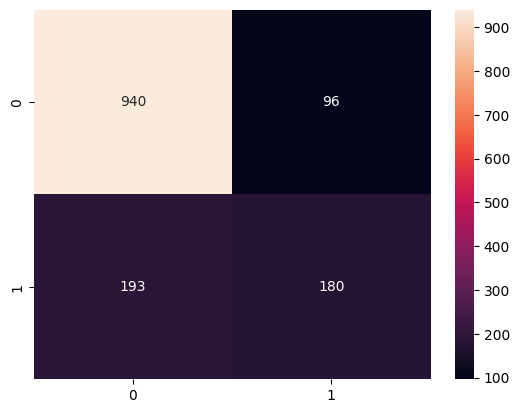

In [368]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d")

In [369]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.65      0.48      0.55       373

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



In [370]:
# 4) K-Nearest Neighbors (KNN):
# - Train a KNN classifier with k = 5 using training data

kneighbors = KNeighborsClassifier(n_neighbors=5).fit(X_train, y_train)
kneighbors

KNeighborsClassifier()

In [371]:
y_pred = kneighbors.predict(X_test)
y_pred

array([1, 0, 0, ..., 0, 0, 0])

In [372]:
acc_kn = accuracy_score(y_test, y_pred)
print(f"Accuracy-score: {acc_kn}")

Accuracy-score: 0.772888573456352


In [373]:
print(confusion_matrix(y_test, y_pred))

[[899 137]
 [183 190]]


<Axes: >

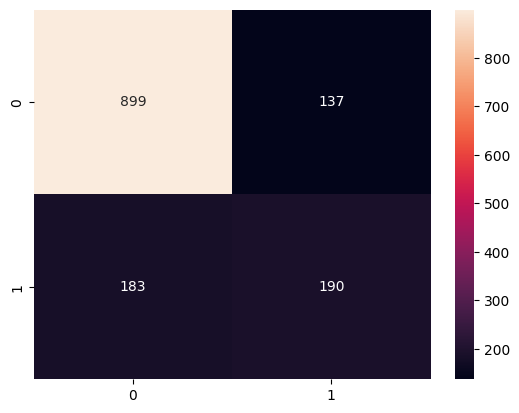

In [374]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d")

In [375]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.87      0.85      1036
           1       0.58      0.51      0.54       373

    accuracy                           0.77      1409
   macro avg       0.71      0.69      0.70      1409
weighted avg       0.76      0.77      0.77      1409



In [376]:
# 5) Naive Bayes:
# - Train a Gaussian Naive Bayes classifier using training data

naive_bayes = GaussianNB().fit(X_train, y_train)
naive_bayes

GaussianNB()

In [377]:
y_pred = naive_bayes.predict(X_test)
y_pred

array([1, 0, 0, ..., 0, 0, 1])

In [378]:
acc_nb = accuracy_score(y_test, y_pred)
print(f"Accuracy-score: {acc_nb}")

Accuracy-score: 0.759403832505323


In [379]:
print(confusion_matrix(y_test, y_pred))

[[782 254]
 [ 85 288]]


<Axes: >

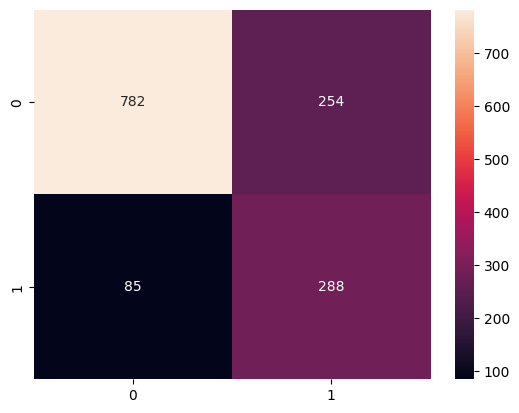

In [380]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d")

In [381]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1036
           1       0.53      0.77      0.63       373

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.76      0.77      1409



In [382]:
# 6) Support Vector Machine (SVM):
# - Train a linear kernel SVM classifier using training data

SVC_classifier = SVC(kernel="linear", random_state=42).fit(X_train, y_train)
SVC_classifier

SVC(kernel='linear', random_state=42)

In [383]:
y_pred = SVC_classifier.predict(X_test)
y_pred

array([1, 0, 0, ..., 0, 0, 0])

In [384]:
acc_svc = accuracy_score(y_test, y_pred)
print(f"Accuracy-score: {acc_svc}")

Accuracy-score: 0.8204400283889283


In [385]:
print(confusion_matrix(y_test, y_pred))

[[937  99]
 [154 219]]


<Axes: >

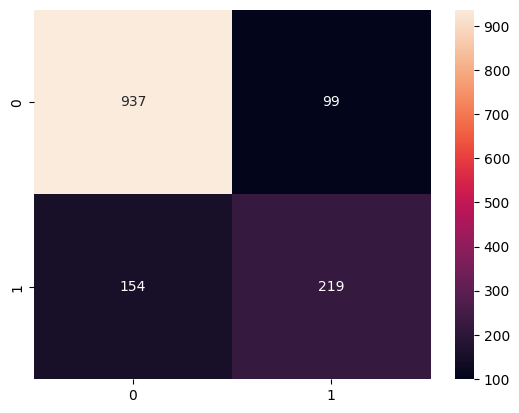

In [386]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d")

In [387]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.59      0.63       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409



In [388]:
# 7) XGBoost:
# - Train an XGBoost classifier using training data and log loss as evaluation metric

xgboost = XGBClassifier(eval_metric="logloss",random_state=42).fit(X_train, y_train)
xgboost

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [389]:
y_pred = xgboost.predict(X_test)
y_pred

array([1, 0, 0, ..., 0, 0, 1])

In [390]:
acc_xgb = accuracy_score(y_test, y_pred)
print(f"Accuracy-score: {acc_xgb}")

Accuracy-score: 0.7863733144073811


In [391]:
print(confusion_matrix(y_test, y_pred))

[[904 132]
 [169 204]]


<Axes: >

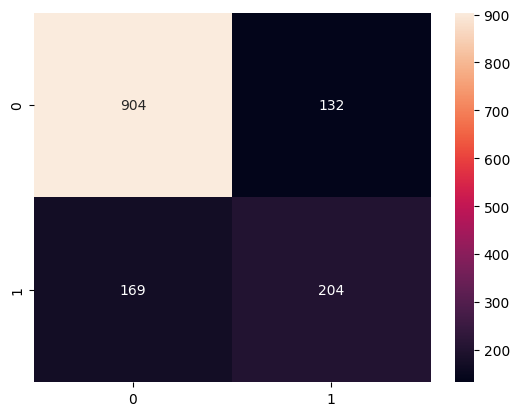

In [392]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d")

In [393]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.87      0.86      1036
           1       0.61      0.55      0.58       373

    accuracy                           0.79      1409
   macro avg       0.72      0.71      0.72      1409
weighted avg       0.78      0.79      0.78      1409



In [394]:
# Store accuracy scores of all trained models for comparison

accuracies = {
    "Logistic Regression": acc_log,
    "Decision Tree": acc_dt,
    "Random Forest": acc_rf,
    "K-Nearest Neighbors": acc_kn,
    "Naive Bayes": acc_nb,
    "Support Vector Machine": acc_svc,
    "XGBoost": acc_xgb

}

In [395]:
# Find the model with the highest accuracy and store its name and score

best_model_name = max(accuracies, key=accuracies.get)
best_accuracy = accuracies[best_model_name]

In [396]:
# Display the best performing model and its accuracy as final conclusion

print("----- Conclusion -----")
print(f"Best supervised model by test accuracy: {best_model_name} (accuracy = {best_accuracy:.4f})")

----- Conclusion -----
Best supervised model by test accuracy: Support Vector Machine (accuracy = 0.8204)
